In [1]:
!pip install --upgrade tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   -- ------------------------------------- 18.6/332.0 MB 79.4 MB/s eta 0:00:04
   -- ------------------------------------- 24.1/332.0 MB 54.5 MB/s eta 0:00:06
   --- ------------------------------------ 30.4/332.0 MB 47.0 MB/s eta 0:00:07
   ---- ----------------------------------- 35.7/332.0 MB 43.2 MB/s eta 0:00:07
   ---- ----------------------------------- 40.9/332.0 MB 38.6 MB/s eta 0:00:08
   ------ --------------------------------- 56.4/332.0 MB 44.8 MB/s eta 0:00:07
   --------- ------------------------------ 76.0/332.0 MB 51.8 MB/s eta 0:00:05
   ----------- ---------------------------- 92.5/332.0 MB 55.3 MB/s eta 0:00:05
   ------------ -------------------------- 110.1/332.0 MB 58.7 MB/s eta 0:00:04
   --------------- ----------------------- 129.0/332.0 MB 61.9 MB/s eta 0:00:04
   ---------------- ---------------------- 137.9/332.0 MB 


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\aml\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense

In [3]:
def iris_mlp(metrics):
    output_activation = "softmax"
    loss = "sparse_categorical_crossentropy"

    input = Input(shape=(4,), name="input")

    x = Dense(
        units=10,
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        activation="relu",
        name="dense_layer1",
    )(input)

    x = Dense(
        units=20,
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        activation="relu",
        name="dense_layer2",
    )(x)

    x = Dense(
        units=10,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        name="dense_layer3",
    )(x)

    output = Dense(units=3, activation=output_activation)(x)

    model = tf.keras.Model(input, output)

    model.compile(optimizer="adam", loss=loss, metrics=metrics)

    return model

In [6]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
data_df = iris.frame
data_df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]


train_df, val_test_df = train_test_split(
    data_df,
    test_size=0.3, # 30% goes to the combined test/validation pool
    random_state=42
)

val_df, test_df = train_test_split(
    val_test_df,
    test_size=0.5, # 50% of the remaining data
    random_state=42
)

# Training Data
train_labels = np.array(train_df.pop("class"))
train_np = np.array(train_df)

# Validation Data
val_labels = np.array(val_df.pop("class"))
val_np = np.array(val_df)

# Test/Inference Data
test_labels = np.array(test_df.pop("class"))
test_np = np.array(test_df)

In [7]:
EPOCHS = 50
BATCH_SIZE = 32

# Instantiate classifier
classifier = iris_mlp(metrics=["accuracy"])

# Fit classifier
history = classifier.fit(
    x=train_np,
    y=train_labels,
    validation_data=(val_np, val_labels),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=2
)

Epoch 1/50
4/4 - 1s - 204ms/step - accuracy: 0.3524 - loss: 2.1162 - val_accuracy: 0.2727 - val_loss: 2.0840
Epoch 2/50
4/4 - 0s - 20ms/step - accuracy: 0.3524 - loss: 1.8270 - val_accuracy: 0.2727 - val_loss: 1.8162
Epoch 3/50
4/4 - 0s - 21ms/step - accuracy: 0.3524 - loss: 1.5744 - val_accuracy: 0.2727 - val_loss: 1.5930
Epoch 4/50
4/4 - 0s - 20ms/step - accuracy: 0.3524 - loss: 1.3706 - val_accuracy: 0.2727 - val_loss: 1.4131
Epoch 5/50
4/4 - 0s - 20ms/step - accuracy: 0.3524 - loss: 1.2083 - val_accuracy: 0.2727 - val_loss: 1.2729
Epoch 6/50
4/4 - 0s - 19ms/step - accuracy: 0.3524 - loss: 1.0718 - val_accuracy: 0.2727 - val_loss: 1.1817
Epoch 7/50
4/4 - 0s - 19ms/step - accuracy: 0.3524 - loss: 0.9832 - val_accuracy: 0.2727 - val_loss: 1.1168
Epoch 8/50
4/4 - 0s - 20ms/step - accuracy: 0.3714 - loss: 0.9407 - val_accuracy: 0.3182 - val_loss: 1.0756
Epoch 9/50
4/4 - 0s - 19ms/step - accuracy: 0.4667 - loss: 0.9162 - val_accuracy: 0.3182 - val_loss: 1.0511
Epoch 10/50
4/4 - 0s - 20ms

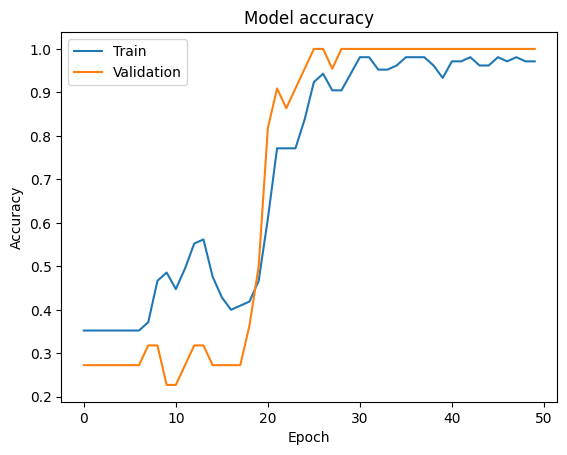

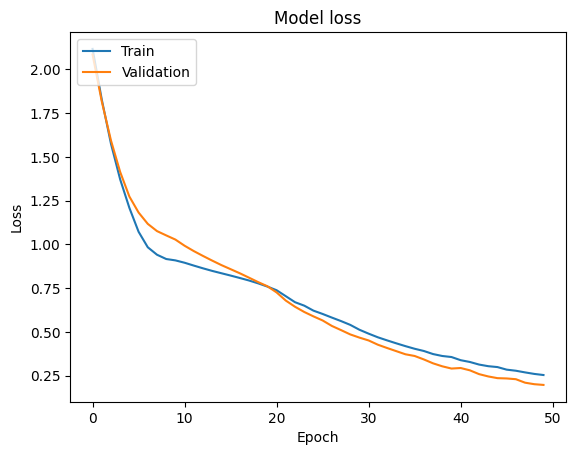

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [10]:
import os
import tarfile

os.makedirs("model/1", exist_ok=True)

classifier.save("model/1/model.keras")

with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("model/1", arcname="model/1")

In [11]:
import pandas as pd
import numpy as np
import os

DATA_PATH = "Data"
os.makedirs(DATA_PATH, exist_ok=True)

# Convert the NumPy array directly to a DataFrame for easy CSV export
batch_df = pd.DataFrame(test_np)

batch_df.to_csv(f"{DATA_PATH}/batch-iris-data.csv", header=False, index=False)
print(f"Batch inference data saved to {DATA_PATH}/batch-iris-data.csv (contains {len(test_np)} records).")

Batch inference data saved to Data/batch-iris-data.csv (contains 23 records).
